Using device: cpu


Processing...
Done!


Total parameters: 92,297

NCPP: Heat-Kernel Coherence-Gated Polynomial Propagation (no spectral filter)
-> rho_i = mean_j exp(-||h_hat_i - h_hat_j||^2 / tau)  [Green's function]
-> Static, H0-anchored (collapse-immune by construction)
-> Per-channel diffusion ceiling (kept); hop-depth spectral filter REMOVED

Epoch  50 | CLS: 0.5052 | Train: 0.9929 | Val: 0.7800 | alpha_mean=0.938 | tau=0.3723 | rho_std=0.0160
Epoch 100 | CLS: 0.3773 | Train: 0.9929 | Val: 0.7940 | alpha_mean=0.928 | tau=0.2730 | rho_std=0.0067
Epoch 150 | CLS: 0.3351 | Train: 1.0000 | Val: 0.7920 | alpha_mean=0.912 | tau=0.2116 | rho_std=0.0035
Epoch 200 | CLS: 0.3791 | Train: 1.0000 | Val: 0.7920 | alpha_mean=0.895 | tau=0.1885 | rho_std=0.0024
Epoch 250 | CLS: 0.3804 | Train: 1.0000 | Val: 0.7800 | alpha_mean=0.885 | tau=0.1724 | rho_std=0.0013
Epoch 300 | CLS: 0.2716 | Train: 1.0000 | Val: 0.7900 | alpha_mean=0.883 | tau=0.1633 | rho_std=0.0020
Early stopping at epoch 337

OPTIMAL VALIDATION ACCURACY: 0.8180
FINAL 

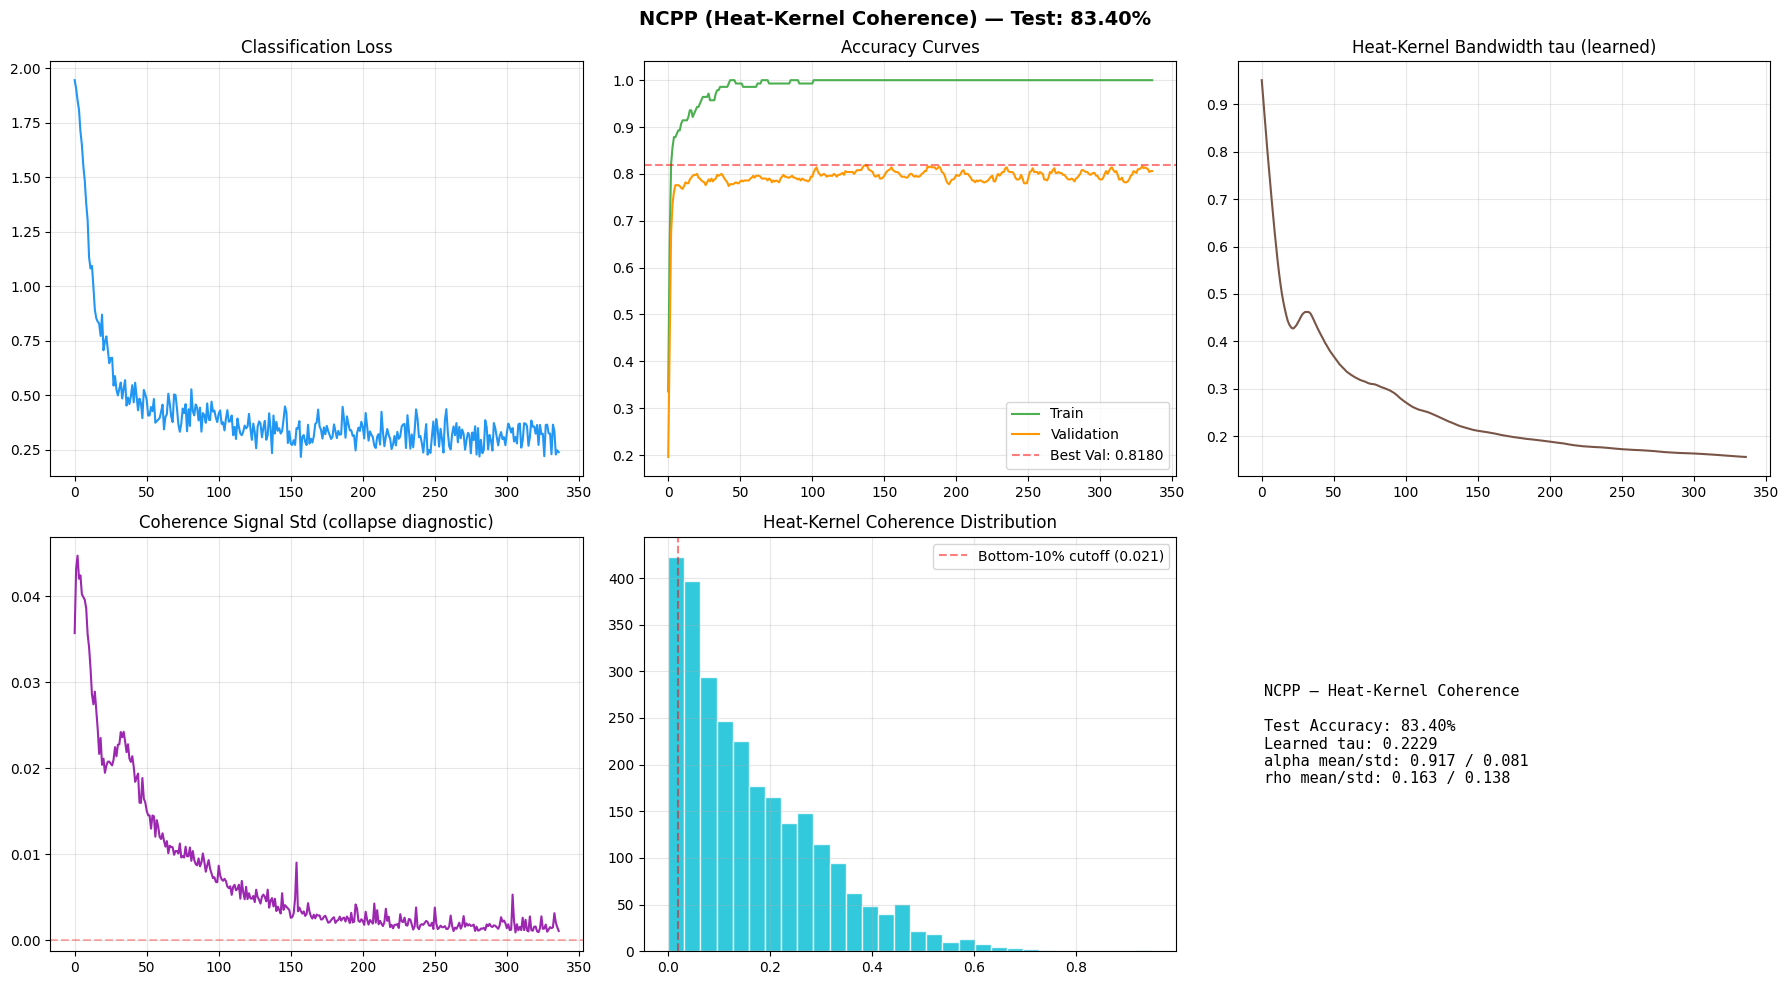

In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import scatter
import matplotlib.pyplot as plt
import numpy as np

torch.sparse.check_sparse_tensor_invariants.disable()
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# =============================================================================
# CELL 1: Dataset & Normalized Adjacency
#
# Physics gcn: builds the symmetric normalized graph propagation operator
#       A_hat = D^{-1/2} (A + I) D^{-1/2}
# which discretizes the graph Laplacian L = I - A_hat used throughout the
# heat-diffusion update in Cell 2. Self-loops (A + I) guarantee every node
# retains a path to itself; D^{-1/2}(.)D^{-1/2} prevents high-degree nodes
# from dominating purely by edge count.
# =============================================================================
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0].to(device)


def build_adj_matrix(edge_index, num_nodes):
    """Build D^{-1/2} (A+I) D^{-1/2} — symmetric normalized adjacency with self-loops."""
    self_loops = torch.arange(num_nodes, device=edge_index.device).unsqueeze(0).repeat(2, 1)
    edge_index_sl = torch.cat([edge_index, self_loops], dim=1)

    row = edge_index_sl[0]
    deg = torch.zeros(num_nodes, device=edge_index.device)
    deg.scatter_add_(0, row, torch.ones(row.size(0), device=edge_index.device))

    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0.0

    src, dst = edge_index_sl
    norm_vals = deg_inv_sqrt[src] * deg_inv_sqrt[dst]

    return torch.sparse_coo_tensor(
        edge_index_sl, norm_vals, (num_nodes, num_nodes)
    ).coalesce()


adj = build_adj_matrix(data.edge_index, data.num_nodes)

# Plain edge index (no self-loops, no normalization) — needed for the per-edge heat-kernel distance computation in Cell
# Self-loops would trivially contribute distance=0 ("a node is heat-kernel-identical to itself"), polluting the true neighbor-coherence measurement.

# =============================================================================
# CELL 2: NCPP Physics Engine — Heat-Kernel Coherence
# =============================================================================
class NCPPPhysics(nn.Module):
    """

    Mechanism:
      1. PER-CHANNEL DIFFUSION CEILING ( heat equation):
            alpha_j = sigmoid(raw_alpha_j) in (0,1)
         Each of the 64 hidden channels gets its own diffusion rate ceiling,
         analogous to a diagonal diffusion tensor D = diag(alpha_1..alpha_64)
         in the heat equation dH/dt = -D . L . H.

      2. HEAT-KERNEL COHERENCE (the novel + physics-explicit signal),
         computed ONCE from H0 (pre-diffusion), never recomputed from the
         diffusing state:
            h_hat_i  = h_i / ||h_i||      (project to unit hypersphere)
            rho_i    = mean_{j in N(i)} exp( -||h_hat_i - h_hat_j||^2 / tau )
         This is the heat equation's Green's function K(x,y;tau) =
         exp(-||x-y||^2/tau).

      3. POLYNOMIAL-DEGREE GATE: rho_i selects the effective hop-degree of
         propagation for the entire K-step trajectory:
            g_i        = sigmoid(beta * (rho_i - 0.5))
            A_blend_i  = g_i * (A_hat H)_i + (1 - g_i) * (A_hat^2 H)_i
            eff_rate   = alpha_j * g_i
            H_{t+1}    = (1 - eff_rate) H_t + eff_rate * A_blend
         The FINAL state H^(K) after K steps is used directly as the
         representation Z



    """

    def __init__(self, hidden_dim, K=10):
        super().__init__()
        self.K = K
        self.hidden_dim = hidden_dim

        # Per-channel diffusion ceiling, symmetry-broken init near alpha=0.95

        # SLOW DOWN specific channels rather than learn diffusion from cold).
        init_alpha = torch.randn(hidden_dim) * 0.5 + 3.0
        self.raw_alpha = nn.Parameter(init_alpha)

        # Heat-kernel bandwidth tau, parameterized as exp(raw_tau) to
        # guarantee tau > 0, and CLAMPED to [0.1, 5.0] to prevent kernel collapse

        self.raw_tau = nn.Parameter(torch.tensor(0.0))  # tau = exp(0) = 1.0 initially

        # Gate sharpness: rescales (rho - 0.5) into a clean sigmoid gate.
        # Centered at 0.5 because rho in (0,1] now (heat-kernel range).

        self.coherence_temp = nn.Parameter(torch.tensor(4.0))

    def get_diffusion_rates(self):
        """alpha_j = sigmoid(raw_alpha_j), per-channel diffusion ceiling in (0,1)."""
        return torch.sigmoid(self.raw_alpha)

    def get_tau(self):
        """tau = exp(raw_tau), clamped to [0.1, 5.0] — heat-kernel bandwidth, always > 0."""
        return torch.exp(self.raw_tau).clamp(0.1, 5.0)

    def _heat_kernel_coherence(self, H, edge_index):
        """
        Compute rho_i = mean_{j in N(i)} exp(-||h_hat_i - h_hat_j||^2 / tau),
        the heat-kernel

          1. Normalize every node's vector to the unit hypersphere: h_hat = h/||h||
          2. Gather h_hat_i, h_hat_j for every edge (i,j) directly from the
             edge list — O(E) work (E ~ 5,400 for Cora), avoiding an O(N^2)
             dense pairwise-distance matrix (~7.3M entries, wasted on a
             graph with <0.1% edge density).
          3. Compute squared distance per edge: ||h_hat_i - h_hat_j||^2
             on the unit hypersphere).
          4. Apply the heat kernel exp(-dist/tau) PER EDGE, then average
             over each node's neighbors via scatter-mean. Exponentiating
             before averaging (rather than averaging distances first) means
             one very dissimilar neighbor is down-weighted, not
             catastrophic to the whole node's score.
        """
        H_unit = H / H.norm(dim=1, keepdim=True).clamp_min(1e-8)  # project to unit hypersphere

        src, dst = edge_index[0], edge_index[1]      # src = i, dst = j (j in N(i))
        h_i = H_unit[src]                              # [E, F]
        h_j = H_unit[dst]                              # [E, F]
        sq_dist = ((h_i - h_j) ** 2).sum(dim=1)        # [E], ||h_hat_i - h_hat_j||^2 per edge

        tau = self.get_tau()
        edge_kernel = torch.exp(-sq_dist / tau)         # [E], heat-kernel value per edge

        rho = scatter(edge_kernel, src, dim=0, dim_size=H.size(0), reduce='mean')  # [N]
        return rho  # in (0, 1], 1 = identical neighbor, ->0 = maximally dissimilar

    def forward(self, H0, adj, edge_index):
        alpha = self.get_diffusion_rates()             # [hidden_dim], per-channel ceiling

        # Heat-kernel coherence, computed ONCE from H0
        # Fixed for the entire K-step trajectory
        rho = self._heat_kernel_coherence(H0, edge_index)        # [N], in (0, 1]
        gate = torch.sigmoid(self.coherence_temp * (rho - 0.5))   # [N] in (0,1)
        gate_col = gate.unsqueeze(1)                                # [N, 1] for broadcasting

        H = H0

        for _ in range(self.K):
            AH = torch.sparse.mm(adj, H)                # 1-hop term: A_hat H
            AAH = torch.sparse.mm(adj, AH)              # 2-hop term: A_hat^2 H
;
            # low coherence -> reach further (2-hop), gated per-node.
            A_blend = gate_col * AH + (1.0 - gate_col) * AAH

            # Effective rate = per-channel ceiling * per-node gate.
            eff_rate = alpha.unsqueeze(0) * gate_col


            #   H_{t+1} = (1 - eff_rate) * H_t + eff_rate * A_blend
            H = (1.0 - eff_rate) * H + eff_rate * A_blend

        # Final diffused state used directly
        return H, rho.detach()


# =============================================================================
# CELL 3: Full Model
# =============================================================================
class NCPPGNN(nn.Module):
    def __init__(self, in_features, hidden, num_classes, K=10, dropout=0.6):
        super().__init__()
        self.encoder = nn.Linear(in_features, hidden)
        self.physics = NCPPPhysics(hidden, K)
        self.decoder = nn.Linear(hidden, num_classes)
        self.dropout = dropout

    def forward(self, x, adj, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        H = F.relu(self.encoder(x))                      # H0 = ReLU(W_enc . x + b)
        H = F.dropout(H, p=self.dropout, training=self.training)

        H_res, rho = self.physics(H, adj, edge_index)

        H_res = F.dropout(H_res, p=self.dropout, training=self.training)
        out = self.decoder(H_res)                          # logits = W_dec . Z + b

        return F.log_softmax(out, dim=1), rho, H_res


model = NCPPGNN(
    in_features=dataset.num_node_features,
    hidden=64,
    num_classes=dataset.num_classes,
    K=10,
    dropout=0.6
).to(device)

print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

# =============================================================================
# CELL 4: Training Configuration
# =============================================================================
physics_params = [model.physics.raw_alpha, model.physics.coherence_temp, model.physics.raw_tau]

optimizer = torch.optim.Adam([
    {'params': model.encoder.parameters(), 'lr': 0.01, 'weight_decay': 5e-3},  # strong WD: only 140 labels
    {'params': model.decoder.parameters(), 'lr': 0.01, 'weight_decay': 0.0},
    {'params': physics_params, 'lr': 0.05, 'weight_decay': 0.0},               # higher LR: saturating gradients
])


def train():
    model.train()
    optimizer.zero_grad()
    out, rho, H_final = model(data.x, adj, edge_index_plain)
    cls_loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])  # L_NLL = -log p(y_i | x_i)
    cls_loss.backward()
    optimizer.step()
    return cls_loss.item(), rho


@torch.no_grad()
def evaluate(mask):
    model.eval()
    out, _, _ = model(data.x, adj, edge_index_plain)
    pred = out.argmax(dim=1)
    return (pred[mask] == data.y[mask]).sum().item() / mask.sum().item()


# =============================================================================
# CELL 5: Training Loop
# =============================================================================
EPOCHS = 500
history = {'cls_loss': [], 'train_acc': [], 'val_acc': [], 'rho_std': [], 'tau': []}
best_val_acc = 0.0
best_state = None
patience = 200
no_improve = 0

print(f"\n{'='*60}")
print("NCPP: Heat-Kernel Coherence-Gated Polynomial Propagation (no spectral filter)")
print("-> rho_i = mean_j exp(-||h_hat_i - h_hat_j||^2 / tau)  [Green's function]")
print("-> Static, H0-anchored (collapse-immune by construction)")
print("-> Per-channel diffusion ceiling (kept); hop-depth spectral filter REMOVED")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    cls_loss, rho = train()
    train_acc = evaluate(data.train_mask)
    val_acc = evaluate(data.val_mask)
    rho_std = rho.std().item()
    tau_val = model.physics.get_tau().item()

    history['cls_loss'].append(cls_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['rho_std'].append(rho_std)
    history['tau'].append(tau_val)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 50 == 0:
        with torch.no_grad():
            a = model.physics.get_diffusion_rates()
        print(f'Epoch {epoch:3d} | CLS: {cls_loss:.4f} | Train: {train_acc:.4f} | Val: {val_acc:.4f} '
              f'| alpha_mean={a.mean().item():.3f} | tau={tau_val:.4f} | rho_std={rho_std:.4f}')

    if no_improve >= patience:
        print(f'Early stopping at epoch {epoch}')
        break

# =============================================================================
# CELL 6: Final Evaluation & Diagnostics
# =============================================================================
model.load_state_dict(best_state)
test_acc = evaluate(data.test_mask)

print(f'\n{"="*60}')
print(f'OPTIMAL VALIDATION ACCURACY: {best_val_acc:.4f}')
print(f'FINAL TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'{"="*60}')

with torch.no_grad():
    out, rho, H_final = model(data.x, adj, edge_index_plain)
    alpha = model.physics.get_diffusion_rates()
    tau = model.physics.get_tau()

    print(f'\nLearned Per-Channel Diffusion Ceiling:')
    print(f'  Mean alpha:  {alpha.mean().item():.4f}')
    print(f'  Std alpha:   {alpha.std().item():.4f}')

    print(f'\nHeat-Kernel Bandwidth (learned):')
    print(f'  tau = {tau.item():.4f}')

    print(f'\nHeat-Kernel Coherence Signal (rho_i, fixed from H0):')
    print(f'  Mean rho:    {rho.mean().item():.4f}')
    print(f'  Std rho:     {rho.std().item():.4f}  '
          f'<- KEY DIAGNOSTIC. If near 0, the gate has collapsed.')
    print(f'  Min / Max rho: {rho.min().item():.4f} / {rho.max().item():.4f}')

    boundary_cutoff = torch.quantile(rho, 0.1)
    print(f'  Bottom-10% coherence cutoff: rho <= {boundary_cutoff.item():.4f}')


    pred = out.argmax(dim=1)
    correct = (pred == data.y).float()
    boundary_mask = rho <= boundary_cutoff
    if (boundary_mask & data.test_mask).sum() > 0 and ((~boundary_mask) & data.test_mask).sum() > 0:
        acc_boundary = correct[boundary_mask & data.test_mask].mean().item()
        acc_nonboundary = correct[(~boundary_mask) & data.test_mask].mean().item()
        print(f'\nValidity check — does low heat-kernel coherence predict harder nodes?')
        print(f'  Test accuracy, bottom-10%-coherence nodes: {acc_boundary:.4f}')
        print(f'  Test accuracy, remaining nodes:            {acc_nonboundary:.4f}')
        print(f'  Gap: {(acc_nonboundary - acc_boundary)*100:.1f} percentage points')

# =============================================================================
# CELL 7: Visualization
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(history['cls_loss'], color='#2196F3')
axes[0, 0].set_title('Classification Loss')
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history['train_acc'], label='Train', color='#4CAF50')
axes[0, 1].plot(history['val_acc'], label='Validation', color='#FF9800')
axes[0, 1].axhline(y=best_val_acc, color='red', linestyle='--', alpha=0.5,
                    label=f'Best Val: {best_val_acc:.4f}')
axes[0, 1].set_title('Accuracy Curves')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[0, 2].plot(history['tau'], color='#795548')
axes[0, 2].set_title('Heat-Kernel Bandwidth tau (learned)')
axes[0, 2].grid(alpha=0.3)

axes[1, 0].plot(history['rho_std'], color='#9C27B0')
axes[1, 0].set_title('Coherence Signal Std (collapse diagnostic)')
axes[1, 0].axhline(y=0.0, color='red', linestyle='--', alpha=0.3)
axes[1, 0].grid(alpha=0.3)

with torch.no_grad():
    rho_np = rho.cpu().numpy()
    cutoff_val = torch.quantile(rho, 0.1).item()
axes[1, 1].hist(rho_np, bins=30, color='#00BCD4', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(x=cutoff_val, color='red', linestyle='--', alpha=0.5,
                    label=f'Bottom-10% cutoff ({cutoff_val:.3f})')
axes[1, 1].set_title('Heat-Kernel Coherence Distribution')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

axes[1, 2].axis('off')
summary_text = (
    f"NCPP — Heat-Kernel Coherence\n\n"
    f"Test Accuracy: {test_acc*100:.2f}%\n"
    f"Learned tau: {tau.item():.4f}\n"
    f"alpha mean/std: {alpha.mean().item():.3f} / {alpha.std().item():.3f}\n"
    f"rho mean/std: {rho.mean().item():.3f} / {rho.std().item():.3f}\n"
)
axes[1, 2].text(0.05, 0.5, summary_text, fontsize=11, family='monospace', va='center')

plt.suptitle(f'NCPP (Heat-Kernel Coherence) — Test: {test_acc*100:.2f}%', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ncpp_heat_kernel_results.png', dpi=150, bbox_inches='tight')
plt.show()